In [1]:
import sys
sys.path.append("C:/Users/19199/Desktop/automated-sca/src")

from camera import *
# import cv2 as cv
import matplotlib.pyplot as plt

from stage import Stage
from plate import Plate
from chip import Chip
import serial
import time

c = Chip()
p = Plate()
# p = Plate(2,3,40000) # roughly the diameter for 6-well plate, a little off
# p = Plate()
s = Stage(p, c)


KeyboardInterrupt: 

In [1]:
import matplotlib.pyplot as plt
import sys
sys.path.append("C:/Users/19199/Desktop/automated-sca/src")
from camera import *
from PIL import Image

In [2]:
cam = Camera()

In [3]:
cam.mmc.setExposure(300)


uint16
197 275
uint8
171


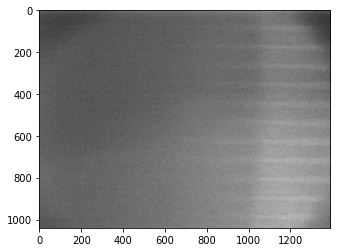

In [11]:
img = cam.getImage()
print(img.dtype)
outerVal = np.min(img) # black
innerVal = np.max(img) # white

print(img.dtype)


# img[100, :] = 255
print(np.max(img))
plt.imshow(img, cmap='gray')
# min = 190, max = 1054 without contrast
# min = 1, max = 244 with contrast
# keep contrast on
pilIm = Image.fromarray(img)
pilIm.show()

In [4]:
numRows, numCols = img.shape
# print(numRows, numCols)
centerPixel = img[numRows//2, numCols//2]
print(centerPixel)

2


In [5]:
blackCeil = 20
numRows, numCols = img.shape

In [6]:
# move to point A
# move right until you are touching the boundary (move right by moving stage left)


print("Moving for A")


centerPixel = img[numRows//2, numCols//2]
print(centerPixel)

while centerPixel < blackCeil:
    s.moveXInUM(-10)
    img = cam.getImage()
    centerPixel = img[numRows//2, numCols//2]
    print(centerPixel)

print("DONE")
pointA = s.getStageXY()
print(pointA)

# 22.7s



Moving for A
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
3
2
2
3
2
2
2
2
3
2
2
3
2
3
3
3
2
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
4
4
3
3
4
4
5
4
4
4
4
4
4
4
4
4
5
5
5
6
6
8
7
10
15
26
DONE
[-3324831, -428824]


In [7]:
print("Moving for B")
# now we are looking at some point inside the well, centerPixel >= blackCeil
while centerPixel >= blackCeil and img[numRows//2, numCols//2+1] >= blackCeil:
    s.moveXInUM(-30)
    img = cam.getImage()
    centerPixel = img[numRows//2, numCols//2]
    print(centerPixel)

print("DONE")
pointB = s.getStageXY()
print(pointB)


while centerPixel < blackCeil:
    s.moveXInUM(2)
    img = cam.getImage()
    centerPixel = img[numRows//2, numCols//2]
    print(centerPixel)

print("DONE")
pointB = s.getStageXY()
print(pointB)
# microadjustment to get back onto white


# 1m 11.9s with -20 movement


Moving for B
227
238
244
247
187
248
248
247
248
244
240
239
237
234
230
229
229
226
220
219
216
214
211
208
206
205
202
198
195
192
189
188
185
180
180
178
175
176
171
172
169
170
169
169
168
166
165
163
160
164
166
163
160
160
161
160
161
160
160
160
158
159
158
156
155
156
156
155
155
157
156
156
156
156
154
152
153
153
153
151
152
152
153
154
153
151
152
152
151
151
151
152
149
150
153
151
153
151
152
151
151
151
153
153
152
153
154
152
152
154
155
156
152
155
156
156
156
160
162
163
163
166
167
168
169
174
175
176
178
180
183
185
189
190
190
194
193
195
197
200
200
203
203
205
180
191
204
208
212
215
217
221
225
228
234
31
DONE
[-3441832, -428803]
DONE
[-3441832, -428803]


In [8]:
print("Moving for C")
# Assume we are just outisde the wall (so touching black now)
# Move down (by moving stage up) to get to point C
while centerPixel >= blackCeil and img[numRows//2+1, numCols//2] >=blackCeil:
    s.moveYInUM(-30)
    img = cam.getImage()
    centerPixel = img[numRows//2, numCols//2]
    print(centerPixel)

print("DONE")
pointC = s.getStageXY()
print(pointC)

# microadjust

while centerPixel < blackCeil:
    s.moveYInUM(2)
    img = cam.getImage()
    centerPixel = img[numRows//2, numCols//2]
    print(centerPixel)

print("DONE")
pointC = s.getStageXY()
print(pointC)
    

Moving for C
235
230
226
220
217
216
213
210
208
207
203
203
201
200
199
196
195
193
192
190
187
187
185
183
181
180
176
174
173
171
168
167
168
164
162
162
162
162
163
161
159
159
158
159
159
158
160
160
160
161
161
161
163
166
165
165
166
166
167
167
170
169
170
173
175
173
175
176
175
178
179
179
183
182
185
185
185
190
188
188
187
190
189
188
187
189
191
192
193
194
194
194
195
198
197
196
198
199
200
199
198
198
200
199
200
204
204
204
204
206
201
194
193
208
210
211
211
212
212
213
215
214
217
220
220
223
223
222
225
229
231
230
234
235
238
239
242
241
244
246
246
247
248
248
248
247
246
240
237
208
228
217
203
183
147
12
DONE
[-3441821, -545778]
11
12
12
13
14
15
16
18
19
21
DONE
[-3441821, -545278]


In [11]:
centerX = pointA[0] + (pointC[0] - pointA[0]) // 2
centerY = pointA[1] + (pointC[1] - pointA[1]) // 2
print(centerX, centerY)


-3383326 -487051
